## Keypoint Distribution

In [115]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import json
import sys

sys.path.append(str(Path.cwd().parent.parent))

import conf

HE_KEYPOINT_ANNOTATION_PATH = conf.HE_KEYPOINT_ANNOTATION_PATH

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


n      : 839
min    : 20
max    : 60
median : 37
mean   : 38.0
std    : 11.0


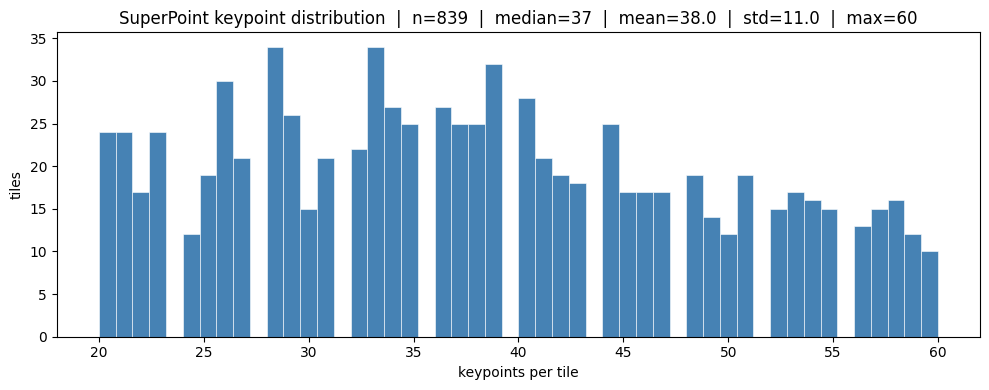

In [116]:
import matplotlib.pyplot as plt

with open(HE_KEYPOINT_ANNOTATION_PATH, "r", encoding="utf-8") as f:
    jobs = json.load(f)

counts = [j["fixed_keypoint_count"] for j in jobs]
mean = sum(counts) / len(counts)
std = (sum((c - mean) ** 2 for c in counts) / len(counts)) ** 0.5
median = sorted(counts)[len(counts) // 2]

print(f"n      : {len(counts)}")
print(f"min    : {min(counts)}")
print(f"max    : {max(counts)}")
print(f"median : {median}")
print(f"mean   : {mean:.1f}")
print(f"std    : {std:.1f}")

fig, ax = plt.subplots(figsize=(10, 4))
bins = range(min(counts), max(counts) + 2)
ax.hist(counts, bins=bins, color="steelblue", edgecolor="white", linewidth=0.4)
ax.set_xlabel("keypoints per tile")
ax.set_ylabel("tiles")
ax.set_title(
    f"SuperPoint keypoint distribution  |  "
    f"n={len(counts)}  |  median={median}  |  "
    f"mean={mean:.1f}  |  std={std:.1f}  |  max={max(counts)}"
)
plt.tight_layout()
plt.show()

## Tiles by Keypoint Count

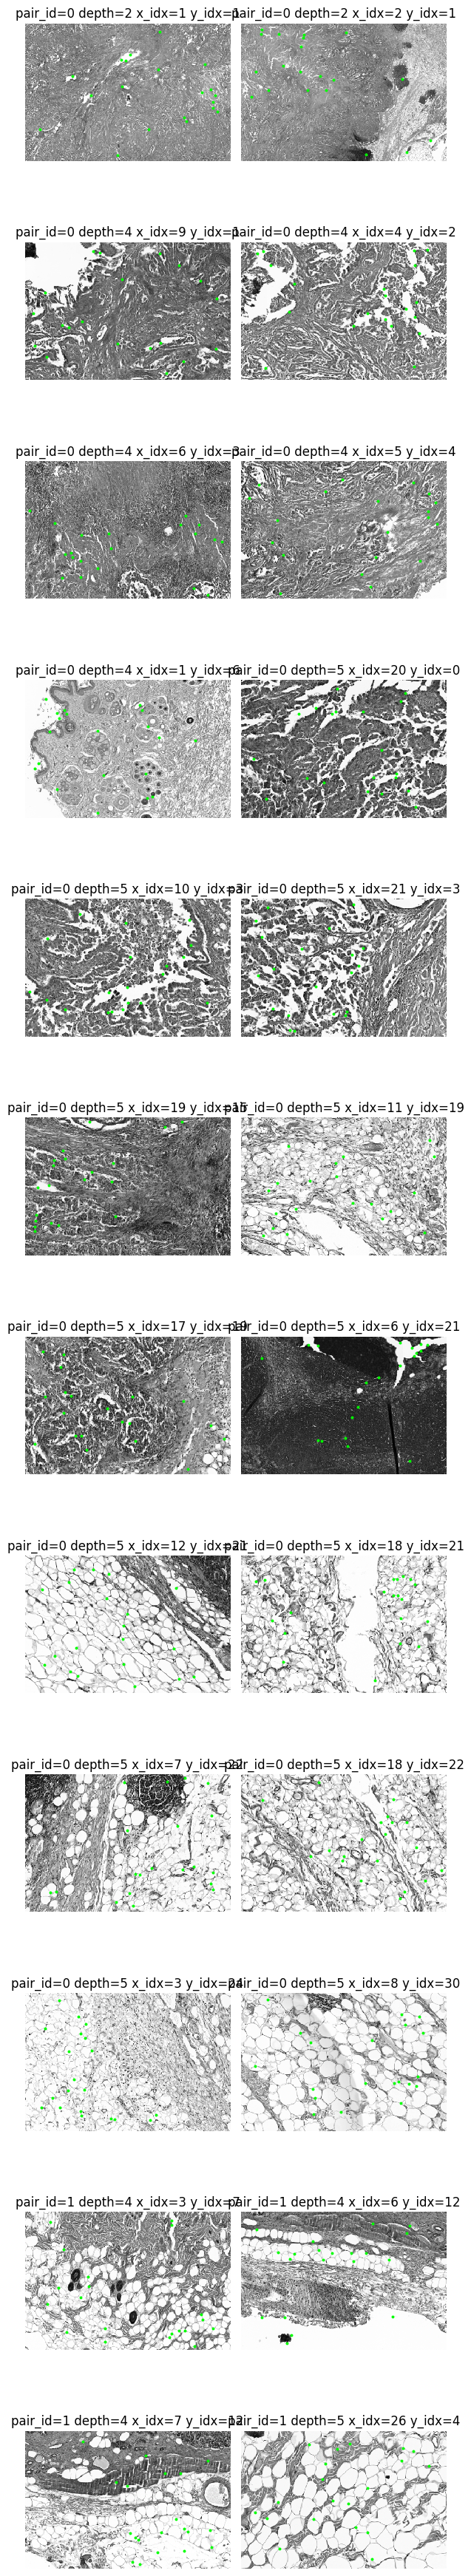

In [117]:
from core.tile_vis import render_tile_grid

KP = 20
N_IMAGES = 30

matching = [j for j in jobs if j["fixed_keypoint_count"] == KP]
if not matching:
    print(f"No tiles with exactly {KP} keypoints")
else:
    render_tile_grid(matching[:N_IMAGES], kp_color="lime",show_moving=False, min_thresh=0.05, exclude_background=True)